# 📱 Análise de Sentimentos — Avaliações do Nubank no Google Play Store

---

| Campo | Detalhe |
|---|---|
| **App analisado** | Nubank (`com.nu.production`) |
| **Técnicas** | VADER (augmentado PT-BR) + TextBlob |
| **Coleta** | `google-play-scraper` |
| **Idioma dos reviews** | Português (Brasil) |

---

## 🎯 Objetivos

1. **Coletar** avaliações do Nubank diretamente do Google Play Store.
2. **Classificar** avaliações em **Positivas**, **Negativas** e **Neutras** com VADER e TextBlob.
3. **Explorar** perguntas analíticas:
   - Como estão as notas da última versão vs. versões anteriores?
   - A quantidade média de curtidas varia de acordo com a nota?
   - O tamanho médio do texto varia de acordo com a nota?
   - O resultado da análise de sentimento bate com a nota dada?

---

> **Nota técnica:** O VADER foi originalmente projetado para inglês.  
> Para suporte ao português, **enriquecemos o léxico do VADER** com mais de 60 termos em PT-BR,  
> tornando a análise linguisticamente adequada para reviews brasileiros.


---
## 1. Configuração e Instalação de Dependências


In [1]:
%%capture
!pip install google-play-scraper vaderSentiment textblob matplotlib seaborn wordcloud pandas numpy scipy tqdm ipywidgets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from google_play_scraper import reviews, Sort, app as gp_app
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
from scipy import stats
import re
import warnings
import os

# tqdm: usa versao notebook se ipywidgets disponivel, senao usa console
try:
    import ipywidgets  # noqa
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")

# Estilo visual
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("whitegrid")

CORES = {
    "positivo" : "#2ecc71",
    "neutro"   : "#3498db",
    "negativo" : "#e74c3c",
    "nubank"   : "#820AD1",
    "cinza"    : "#95a5a6"
}

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
## 2. Coleta de Dados — Google Play Store

Utilizamos a biblioteca `google-play-scraper` para extrair avaliações do **Nubank**,  
o maior banco digital do Brasil com mais de 90 milhões de clientes.


In [2]:
APP_ID       = 'com.nu.production'
REVIEWS_FILE = 'nubank_reviews.csv'
N_REVIEWS    = 2000  # total de reviews a coletar

# ── Informações do app ────────────────────────────────────────────────────────
try:
    app_info = gp_app(APP_ID, lang='pt', country='br')
    print(f"📱 App       : {app_info['title']}")
    print(f"⭐ Nota geral : {app_info['score']:.2f}")
    print(f"💬 Avaliações: {app_info['ratings']:,}")
    print(f"🔢 Versão     : {app_info.get('version', 'N/A')}")
    print(f"🏢 Categoria  : {app_info.get('genre', 'N/A')}")
except Exception as e:
    print(f'Não foi possível obter informações do app: {e}')

📱 App       : Nubank: conta, cartão e mais
⭐ Nota geral : 4.76
💬 Avaliações: 5,497,102
🔢 Versão     : Varies with device
🏢 Categoria  : Finanças


In [3]:
def coletar_reviews(app_id: str, n: int = 2000, lang: str = 'pt', country: str = 'br') -> pd.DataFrame:
    """Coleta reviews do Play Store em lotes de 200."""
    todos_reviews = []
    token = None
    batchsize = 200
    n_lotes = (n // batchsize) + 1

    print(f'Coletando {n} reviews do app "{app_id}"...')
    for _ in tqdm(range(n_lotes), desc='Lotes'):
        lote, token = reviews(
            app_id,
            lang=lang,
            country=country,
            sort=Sort.NEWEST,
            count=batchsize,
            continuation_token=token
        )
        todos_reviews.extend(lote)
        if token is None or len(todos_reviews) >= n:
            break

    df = pd.DataFrame(todos_reviews[:n])
    return df


# ── Cache: evita nova coleta desnecessária ────────────────────────────────────
if os.path.exists(REVIEWS_FILE):
    print(f'📂 Carregando reviews do cache: {REVIEWS_FILE}')
    df_raw = pd.read_csv(REVIEWS_FILE, parse_dates=['at'])
else:
    df_raw = coletar_reviews(APP_ID, n=N_REVIEWS)
    df_raw.to_csv(REVIEWS_FILE, index=False)
    print(f'💾 Reviews salvos em: {REVIEWS_FILE}')

print(f'\n✅ {len(df_raw):,} reviews coletados.')
print(f'📋 Colunas: {list(df_raw.columns)}')

Coletando 2000 reviews do app "com.nu.production"...


Lotes:   0%|          | 0/11 [00:00<?, ?it/s]

💾 Reviews salvos em: nubank_reviews.csv

✅ 2,000 reviews coletados.
📋 Colunas: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [4]:
# ── Seleção e limpeza de colunas relevantes ───────────────────────────────────
colunas = {
    'content'      : 'texto',
    'score'        : 'nota',
    'thumbsUpCount': 'curtidas',
    'at'           : 'data',
    'appVersion'   : 'versao',
    'userName'     : 'usuario'
}

cols_presentes = {k: v for k, v in colunas.items() if k in df_raw.columns}
df = df_raw[list(cols_presentes.keys())].rename(columns=cols_presentes).copy()

# Conversões de tipo
df['nota']     = pd.to_numeric(df['nota'],     errors='coerce').astype('Int64')
df['curtidas'] = pd.to_numeric(df['curtidas'], errors='coerce').fillna(0).astype(int)
df['data']     = pd.to_datetime(df['data'],    errors='coerce', utc=True)
df['texto']    = df['texto'].fillna('').astype(str)
df['versao']   = df['versao'].fillna('Desconhecida').astype(str)

# Comprimento do texto
df['tamanho_texto'] = df['texto'].str.len()

# Remove duplicatas
df.drop_duplicates(subset=['texto', 'nota'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (1576, 7)


,texto,nota,curtidas,data,versao,usuario,tamanho_texto
0,obrigado por nada,1,0,2026-04-11 16:43:55+00:00,9.44.63-minApi28,Eugênio Costa,17
1,muito bom amo muito fazer parte desse banco😉👍🏾👏🏾,5,0,2026-04-11 16:41:45+00:00,9.44.63-minApi28,Wesley Silveira,48
2,sou cliente nubank ultravioleta há algum tempo...,1,0,2026-04-11 16:40:39+00:00,9.24.37-minApi28,daniel aleixo,284


---
## 3. Análise Exploratória dos Dados (EDA)


In [5]:
print('=' * 50)
print('       ESTATÍSTICAS GERAIS DO DATASET')
print('=' * 50)
print(f'  Total de reviews          : {len(df):,}')
print(f'  Nota média                : {df["nota"].mean():.2f}')
print(f'  Nota mediana              : {df["nota"].median():.0f}')
print(f'  Curtidas totais           : {df["curtidas"].sum():,}')
print(f'  Tamanho médio do texto    : {df["tamanho_texto"].mean():.0f} chars')
print(f'  Versões distintas         : {df["versao"].nunique()}')
print(f'  Período                   : {df["data"].min().date()} → {df["data"].max().date()}')
print('=' * 50)

print('\nDistribuição por nota:')
dist = df['nota'].value_counts().sort_index()
for nota, qtd in dist.items():
    pct = qtd / len(df) * 100
    barra = '█' * int(pct / 2)
    print(f'  ⭐ {nota}: {qtd:>5} ({pct:5.1f}%) {barra}')

       ESTATÍSTICAS GERAIS DO DATASET
  Total de reviews          : 1,576
  Nota média                : 3.67
  Nota mediana              : 5
  Curtidas totais           : 156
  Tamanho médio do texto    : 70 chars
  Versões distintas         : 70
  Período                   : 2026-04-03 → 2026-04-11

Distribuição por nota:
  ⭐ 1:   424 ( 26.9%) █████████████
  ⭐ 2:    56 (  3.6%) █
  ⭐ 3:    74 (  4.7%) ██
  ⭐ 4:    81 (  5.1%) ██
  ⭐ 5:   941 ( 59.7%) █████████████████████████████


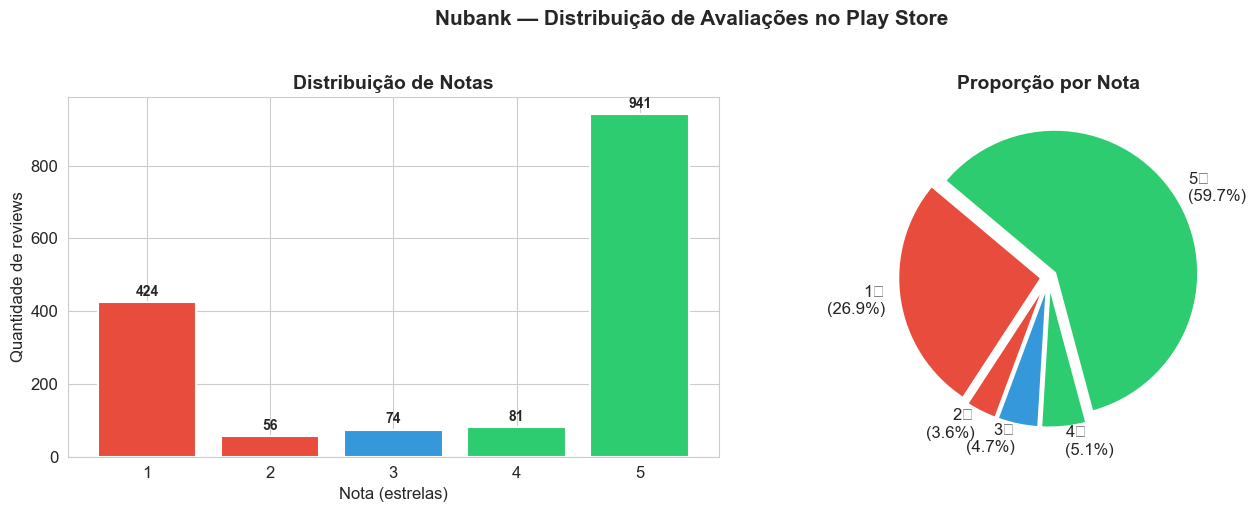

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico de barras: contagem por nota ──────────────────────────────────────
contagem = df['nota'].value_counts().sort_index()
cores_barras = [CORES['negativo'], CORES['negativo'], CORES['neutro'],
                CORES['positivo'], CORES['positivo']]

barras = axes[0].bar(contagem.index, contagem.values,
                     color=cores_barras, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição de Notas')
axes[0].set_xlabel('Nota (estrelas)')
axes[0].set_ylabel('Quantidade de reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

for barra in barras:
    h = barra.get_height()
    axes[0].text(barra.get_x() + barra.get_width() / 2, h + 10,
                 f'{h:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# ── Pizza: proporção ──────────────────────────────────────────────────────────
pct = contagem.values / contagem.values.sum() * 100
labels = [f'{n}⭐\n({p:.1f}%)' for n, p in zip(contagem.index, pct)]
explode = [0.05] * 5

axes[1].pie(contagem.values, labels=labels, colors=cores_barras,
            explode=explode, startangle=140, autopct='',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção por Nota')

plt.suptitle('Nubank — Distribuição de Avaliações no Play Store', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_distribuicao_notas.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Top 10 versões com mais avaliações (pandas 1.x e 2.x compatível) ─────────
top_versoes = (df['versao']
               .value_counts()
               .head(10)
               .rename_axis('versao')
               .reset_index(name='qtd'))

print('Top 10 versões por quantidade de reviews:')
print(top_versoes.to_string(index=False))

Top 10 versões por quantidade de reviews:
          versao  qtd
9.43.95-minApi28  905
9.44.63-minApi28  232
    Desconhecida  202
9.43.77-minApi28   97
 9.43.3-minApi28   10
9.38.75-minApi28   10
 9.42.1-minApi28    9
9.42.65-minApi28    9
9.43.95-minApi23    6
9.41.64-minApi28    6


---
## 4. Análise de Sentimentos

### 4.1 VADER — Valence Aware Dictionary and sEntiment Reasoner

O VADER é uma ferramenta baseada em léxico e regras, ideal para textos curtos como reviews e posts sociais.
Cada texto recebe um **compound score** entre -1 (máximo negativo) e +1 (máximo positivo):

| Compound | Classificação |
|---|---|
| ≥ 0.05 | Positivo |
| ≤ -0.05 | Negativo |
| Entre -0.05 e 0.05 | Neutro |

**Adaptação para PT-BR:** Expandimos o léxico do VADER com 60+ termos em português,  
incluindo palavras positivas, negativas e tratamento de negações.


In [8]:
# ── Léxico customizado PT-BR para o VADER ────────────────────────────────────
lexico_ptbr = {
    # Positivos fortes
    'ótimo': 3.5,     'otimo': 3.5,     'excelente': 3.5,  'maravilhoso': 3.5,
    'fantástico': 3.5,'fantastico': 3.5,'incrível': 3.2,   'incrivel': 3.2,
    'perfeito': 3.2,  'impecável': 3.2, 'impecavel': 3.2,  'sensacional': 3.5,
    'espetacular': 3.5,'nota dez': 3.5, 'top': 2.8,        'show': 2.5,
    'adoro': 3.0,     'amo': 3.0,       'amei': 3.2,       'adorei': 3.2,
    # Positivos moderados
    'bom': 2.0,       'boa': 2.0,       'bons': 2.0,       'boas': 2.0,
    'gosto': 2.0,     'gostei': 2.0,    'rápido': 1.8,     'rapido': 1.8,
    'fácil': 1.8,     'facil': 1.8,     'simples': 1.5,    'prático': 1.8,
    'pratico': 1.8,   'seguro': 2.0,    'confiável': 2.2,  'confiavel': 2.2,
    'recomendo': 2.5, 'funciona': 1.5,  'funcionando': 1.5,'melhor': 2.0,
    'legal': 1.5,     'bacana': 1.5,    'eficiente': 2.0,  'intuitivo': 1.8,
    'prático': 1.8,   'moderno': 1.5,   'inovador': 1.8,   'gratuito': 1.5,
    'aprovado': 2.0,  'satisfeito': 2.2,'satisfeita': 2.2, 'melhora': 1.5,
    # Negativos fortes
    'péssimo': -3.5,  'pessimo': -3.5,  'horrível': -3.5,  'horrivel': -3.5,
    'terrível': -3.2, 'terrivel': -3.2, 'lixo': -3.5,      'ridículo': -3.0,
    'ridiculo': -3.0, 'absurdo': -3.0,  'inaceitável': -3.5,'inaceitavel': -3.5,
    'vergonha': -3.2, 'fraude': -3.5,   'golpe': -3.5,     'roubaram': -3.5,
    'roubou': -3.5,   'golpistas': -3.5,'bloqueou': -2.5,  'bloquearam': -2.5,
    'odeio': -3.5,    'detesto': -3.5,  'horrendo': -3.2,  'inutilizável': -3.5,
    # Negativos moderados
    'ruim': -2.0,     'lento': -2.0,    'trava': -2.5,     'travou': -2.5,
    'travando': -2.5, 'bug': -2.5,      'bugado': -2.5,    'erro': -2.0,
    'erros': -2.0,    'falha': -2.5,    'falhou': -2.5,    'problema': -1.5,
    'problemas': -1.5,'pior': -2.8,     'decepcionante': -2.5,'decepcionei': -2.5,
    'decepcionado': -2.5,'desinstalar': -2.0,'desinstalei': -2.5,'demora': -1.5,
    'demorando': -1.8,'demorado': -1.8, 'complicado': -1.5,'difícil': -1.5,
    'dificil': -1.5,  'impossível': -2.5,'impossivel': -2.5,'caiu': -2.0,
    'caindo': -2.0,   'instável': -2.0, 'instavel': -2.0,  'caro': -1.5,
    'cobram': -1.5,   'cobrança': -1.5, 'cobranca': -1.5,  'inútil': -3.0,
    'inutil': -3.0,
}

# ── Inicializa e augmenta o VADER ─────────────────────────────────────────────
analisador = SentimentIntensityAnalyzer()
analisador.lexicon.update(lexico_ptbr)

print(f'✅ VADER inicializado com léxico PT-BR augmentado.')
print(f'   Termos no léxico original : ~7.500')
print(f'   Termos adicionados (PT-BR): {len(lexico_ptbr)}')

# Teste rápido
testes = [
    'Excelente aplicativo, muito rápido e fácil de usar!',
    'Horrível! Trava o tempo todo, péssimo serviço.',
    'Aplicativo razoável, poderia ser melhor.'
]
print('\nTeste do analisador:')
for t in testes:
    sc = analisador.polarity_scores(t)
    print(f'  "{t[:50]}..."')
    print(f'   compound={sc["compound"]:.3f} | pos={sc["pos"]:.3f} | neg={sc["neg"]:.3f} | neu={sc["neu"]:.3f}')

✅ VADER inicializado com léxico PT-BR augmentado.
   Termos no léxico original : ~7.500
   Termos adicionados (PT-BR): 112

Teste do analisador:
  "Excelente aplicativo, muito rápido e fácil de usar..."
   compound=0.886 | pos=0.675 | neg=0.000 | neu=0.325
  "Horrível! Trava o tempo todo, péssimo serviço...."
   compound=-0.930 | pos=0.000 | neg=0.762 | neu=0.238
  "Aplicativo razoável, poderia ser melhor...."
   compound=0.459 | pos=0.429 | neg=0.000 | neu=0.571


In [9]:
def preprocessar_texto(texto: str) -> str:
    """Limpeza leve — mantém pontuação para o VADER (que usa pontuação como sinal)."""
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)          # remove URLs
    texto = re.sub(r'[^\w\s!?.,áéíóúâêîôûãõàèìòùç]', ' ', texto)  # mantém letras PT + pontuação
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def classificar_vader(compound: float) -> str:
    if compound >= 0.05:
        return 'Positivo'
    elif compound <= -0.05:
        return 'Negativo'
    return 'Neutro'


# ── Aplicar VADER ─────────────────────────────────────────────────────────────
print('Aplicando VADER nos reviews...')
df['texto_limpo'] = df['texto'].apply(preprocessar_texto)

scores_vader = df['texto_limpo'].apply(lambda t: analisador.polarity_scores(t))

df['vader_compound'] = scores_vader.apply(lambda s: s['compound'])
df['vader_pos']      = scores_vader.apply(lambda s: s['pos'])
df['vader_neu']      = scores_vader.apply(lambda s: s['neu'])
df['vader_neg']      = scores_vader.apply(lambda s: s['neg'])
df['sentimento_vader'] = df['vader_compound'].apply(classificar_vader)

print(f'✅ VADER aplicado em {len(df):,} reviews.')

Aplicando VADER nos reviews...
✅ VADER aplicado em 1,576 reviews.


### 4.2 TextBlob

O TextBlob usa análise léxica com suporte a inglês e padrões linguísticos básicos.  
O **polarity score** varia de -1 (negativo) a +1 (positivo).


In [10]:
def analisar_textblob(texto: str):
    analise = TextBlob(texto)
    return analise.sentiment.polarity


def classificar_textblob(polarity: float) -> str:
    if polarity > 0.05:
        return 'Positivo'
    elif polarity < -0.05:
        return 'Negativo'
    return 'Neutro'


print('Aplicando TextBlob nos reviews...')
df['tb_polarity']        = df['texto_limpo'].apply(analisar_textblob)
df['sentimento_textblob'] = df['tb_polarity'].apply(classificar_textblob)

print(f'✅ TextBlob aplicado em {len(df):,} reviews.')

Aplicando TextBlob nos reviews...
✅ TextBlob aplicado em 1,576 reviews.


---
## 5. Resultados da Análise de Sentimentos

### 5.1 Requisito Mínimo — Contagem de Positivos, Negativos e Neutros


In [11]:
def resumo_sentimentos(coluna: pd.Series, nome: str) -> pd.DataFrame:
    contagem = coluna.value_counts()
    total    = len(coluna)
    df_res   = pd.DataFrame({
        'Sentimento': contagem.index,
        'Quantidade': contagem.values,
        'Porcentagem (%)': (contagem.values / total * 100).round(2)
    })
    df_res.insert(0, 'Método', nome)
    return df_res


res_vader    = resumo_sentimentos(df['sentimento_vader'],    'VADER (PT-BR)')
res_textblob = resumo_sentimentos(df['sentimento_textblob'], 'TextBlob')
res_total    = pd.concat([res_vader, res_textblob], ignore_index=True)

print('=' * 60)
print('  CONTAGEM DE SENTIMENTOS — REQUISITO MÍNIMO')
print('=' * 60)
print(res_total.to_string(index=False))
print('=' * 60)
print(f'  Total de reviews analisados: {len(df):,}')

  CONTAGEM DE SENTIMENTOS — REQUISITO MÍNIMO
       Método Sentimento  Quantidade  Porcentagem (%)
VADER (PT-BR)   Positivo         800            50.76
VADER (PT-BR)     Neutro         491            31.15
VADER (PT-BR)   Negativo         285            18.08
     TextBlob     Neutro        1503            95.37
     TextBlob   Positivo          69             4.38
     TextBlob   Negativo           4             0.25
  Total de reviews analisados: 1,576


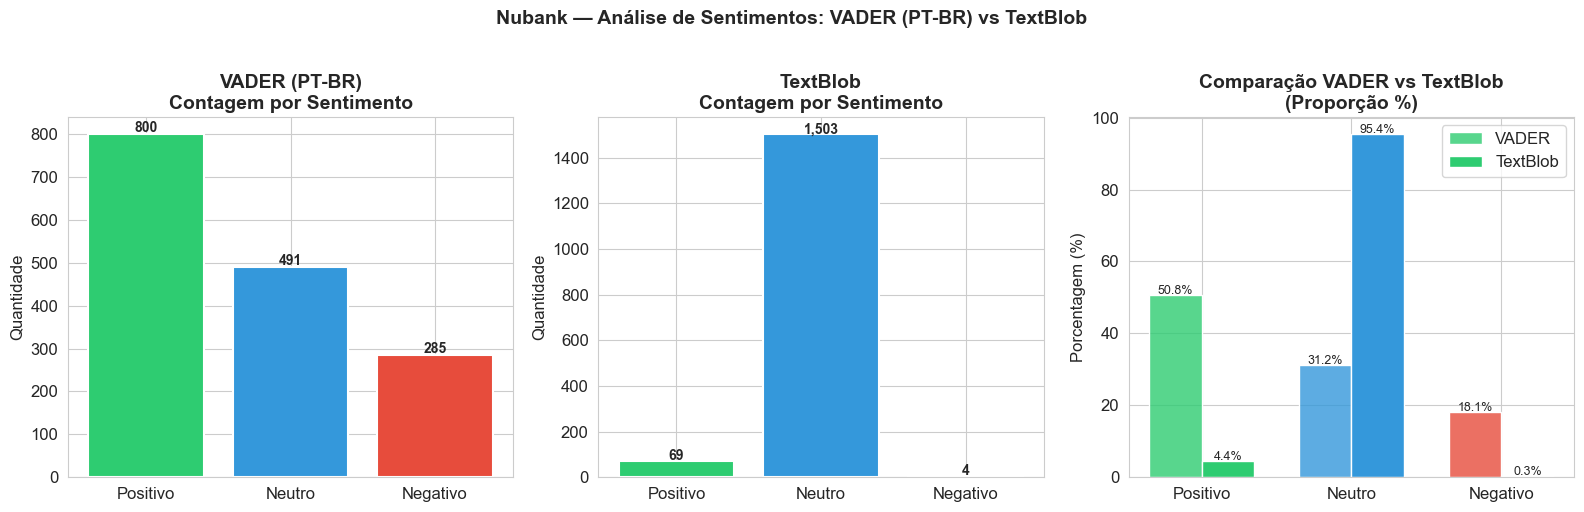

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ordem = ['Positivo', 'Neutro', 'Negativo']
cores_sent = [CORES['positivo'], CORES['neutro'], CORES['negativo']]

# ── 1. VADER — barras ─────────────────────────────────────────────────────────
v_count = df['sentimento_vader'].value_counts().reindex(ordem, fill_value=0)
barras = axes[0].bar(ordem, v_count.values, color=cores_sent, edgecolor='white', linewidth=1.5)
axes[0].set_title('VADER (PT-BR)\nContagem por Sentimento')
axes[0].set_ylabel('Quantidade')
for b in barras:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=10)

# ── 2. TextBlob — barras ──────────────────────────────────────────────────────
t_count = df['sentimento_textblob'].value_counts().reindex(ordem, fill_value=0)
barras2 = axes[1].bar(ordem, t_count.values, color=cores_sent, edgecolor='white', linewidth=1.5)
axes[1].set_title('TextBlob\nContagem por Sentimento')
axes[1].set_ylabel('Quantidade')
for b in barras2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=10)

# ── 3. Comparação proporcional (% lado a lado) ────────────────────────────────
x   = np.arange(len(ordem))
w   = 0.35
pct_v = v_count.values / v_count.sum() * 100
pct_t = t_count.values / t_count.sum() * 100

b1 = axes[2].bar(x - w/2, pct_v, w, label='VADER',    color=[c + 'cc' for c in cores_sent],
                 edgecolor='white')
b2 = axes[2].bar(x + w/2, pct_t, w, label='TextBlob', color=cores_sent, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(ordem)
axes[2].set_ylabel('Porcentagem (%)')
axes[2].set_title('Comparação VADER vs TextBlob\n(Proporção %)')
axes[2].legend()

for b in list(b1) + list(b2):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{b.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Nubank — Análise de Sentimentos: VADER (PT-BR) vs TextBlob',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_sentimentos_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

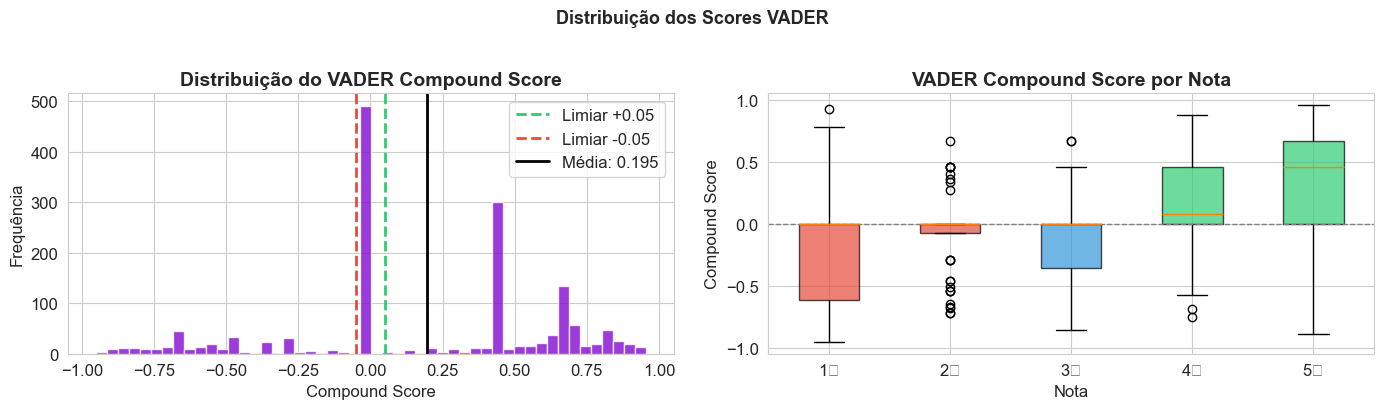

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Histograma do compound score ──────────────────────────────────────────────
axes[0].hist(df['vader_compound'], bins=50, color=CORES['nubank'], edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.05,  color=CORES['positivo'], linestyle='--', linewidth=2, label='Limiar +0.05')
axes[0].axvline(x=-0.05, color=CORES['negativo'], linestyle='--', linewidth=2, label='Limiar -0.05')
axes[0].axvline(x=df['vader_compound'].mean(), color='black', linestyle='-',
                linewidth=2, label=f'Média: {df["vader_compound"].mean():.3f}')
axes[0].set_title('Distribuição do VADER Compound Score')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# ── Boxplot compound por nota ──────────────────────────────────────────────────
data_box = [df[df['nota'] == n]['vader_compound'].dropna().values for n in range(1, 6)]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'])
for patch, cor in zip(bp['boxes'], [CORES['negativo'], CORES['negativo'],
                                     CORES['neutro'], CORES['positivo'], CORES['positivo']]):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('VADER Compound Score por Nota')
axes[1].set_xlabel('Nota')
axes[1].set_ylabel('Compound Score')

plt.suptitle('Distribuição dos Scores VADER', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_vader_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Análises Expandidas

### 6.1 Como estão as notas da última versão? Em relação a outras versões?


In [14]:
# ── Identifica a versão mais recente ─────────────────────────────────────────
contagem_versoes = df['versao'].value_counts()
versoes_relevantes = contagem_versoes[contagem_versoes >= 10].index
df_versoes = df[df['versao'].isin(versoes_relevantes)].copy()

# Estatísticas por versão
stats_versoes = (df_versoes.groupby('versao')
                 .agg(
                     total_reviews=('nota', 'count'),
                     nota_media=('nota', 'mean'),
                     nota_mediana=('nota', 'median'),
                     compound_medio=('vader_compound', 'mean'),
                     pct_positivo=('sentimento_vader', lambda x: (x == 'Positivo').mean() * 100)
                 )
                 .reset_index()
                 .sort_values('total_reviews', ascending=False))

# Versão com mais reviews recentes = "última" (proxy)
ultima_versao = stats_versoes.iloc[0]['versao']
print(f'Versão mais avaliada (proxy para última): {ultima_versao}')
print(f'\nTop 10 versões por nº de reviews:')
print(stats_versoes.head(10).to_string(index=False))

Versão mais avaliada (proxy para última): 9.43.95-minApi28

Top 10 versões por nº de reviews:
          versao  total_reviews  nota_media  nota_mediana  compound_medio  pct_positivo
9.43.95-minApi28            905    3.856354           5.0        0.230296     54.143646
9.44.63-minApi28            232    3.418103           5.0        0.149034     45.258621
    Desconhecida            202    2.990099           3.0        0.070929     43.069307
9.43.77-minApi28             97    4.195876           5.0        0.293243     57.731959
 9.43.3-minApi28             10         4.2           5.0        0.194590     60.000000
9.38.75-minApi28             10         4.2           5.0        0.328280     70.000000


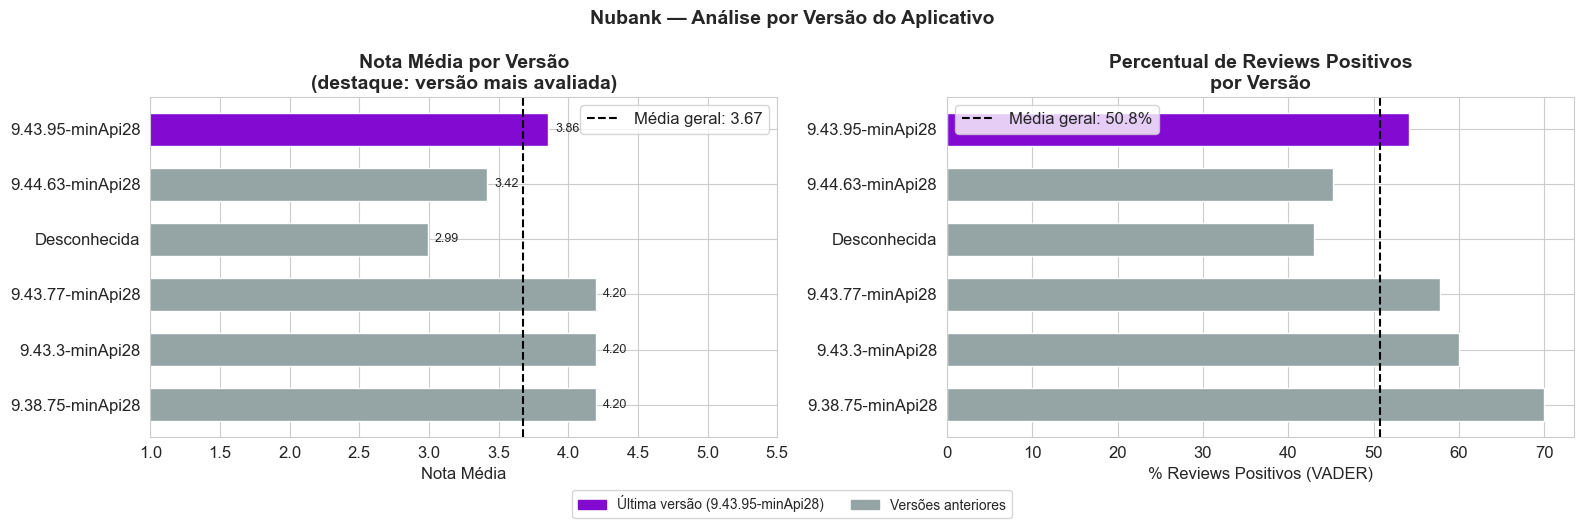


📊 Nota média — última versão : 3.86
📊 Nota média — outras versões: 3.80
   Diferença                  : +0.06


In [15]:
top10 = stats_versoes.head(10).copy()
top10['cor'] = top10['versao'].apply(lambda v: CORES['nubank'] if v == ultima_versao else CORES['cinza'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Nota média por versão ─────────────────────────────────────────────────────
barras = axes[0].barh(top10['versao'][::-1], top10['nota_media'][::-1],
                      color=top10['cor'][::-1].values, edgecolor='white', height=0.6)
axes[0].axvline(x=df['nota'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Média geral: {df["nota"].mean():.2f}')
axes[0].set_xlabel('Nota Média')
axes[0].set_title('Nota Média por Versão\n(destaque: versão mais avaliada)')
axes[0].legend()
axes[0].set_xlim(1, 5.5)
for b, val in zip(barras, top10['nota_media'][::-1].values):
    axes[0].text(val + 0.05, b.get_y() + b.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

# ── % Positivos por versão ─────────────────────────────────────────────────────
axes[1].barh(top10['versao'][::-1], top10['pct_positivo'][::-1],
             color=top10['cor'][::-1].values, edgecolor='white', height=0.6)
media_pos = (df['sentimento_vader'] == 'Positivo').mean() * 100
axes[1].axvline(x=media_pos, color='black', linestyle='--', linewidth=1.5,
                label=f'Média geral: {media_pos:.1f}%')
axes[1].set_xlabel('% Reviews Positivos (VADER)')
axes[1].set_title('Percentual de Reviews Positivos\npor Versão')
axes[1].legend()

legenda_patch = mpatches.Patch(color=CORES['nubank'], label=f'Última versão ({ultima_versao})')
cinza_patch   = mpatches.Patch(color=CORES['cinza'], label='Versões anteriores')
fig.legend(handles=[legenda_patch, cinza_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.suptitle('Nubank — Análise por Versão do Aplicativo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_analise_versoes.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusão textual
nota_ultima = top10.iloc[0]['nota_media']
nota_outras = stats_versoes.iloc[1:]['nota_media'].mean()
print(f'\n📊 Nota média — última versão : {nota_ultima:.2f}')
print(f'📊 Nota média — outras versões: {nota_outras:.2f}')
print(f'   Diferença                  : {nota_ultima - nota_outras:+.2f}')

### 6.2 A quantidade média de curtidas varia de acordo com a nota?


In [16]:
curtidas_por_nota = (df.groupby('nota')['curtidas']
                     .agg(['mean', 'median', 'sum', 'count'])
                     .round(2)
                     .reset_index())
curtidas_por_nota.columns = ['Nota', 'Média', 'Mediana', 'Total', 'Reviews']

print('Curtidas por nota:')
print(curtidas_por_nota.to_string(index=False))

# Teste de correlação (Spearman — dados não normais)
corr, pval = stats.spearmanr(df['nota'].dropna(), df['curtidas'])
print(f'\n🔗 Correlação de Spearman (nota × curtidas): r={corr:.3f}, p={pval:.4f}')

Curtidas por nota:
 Nota  Média  Mediana  Total  Reviews
    1   0.13      0.0     57      424
    2   0.91      0.0     51       56
    3   0.08      0.0      6       74
    4   0.09      0.0      7       81
    5   0.04      0.0     35      941

🔗 Correlação de Spearman (nota × curtidas): r=-0.182, p=0.0000


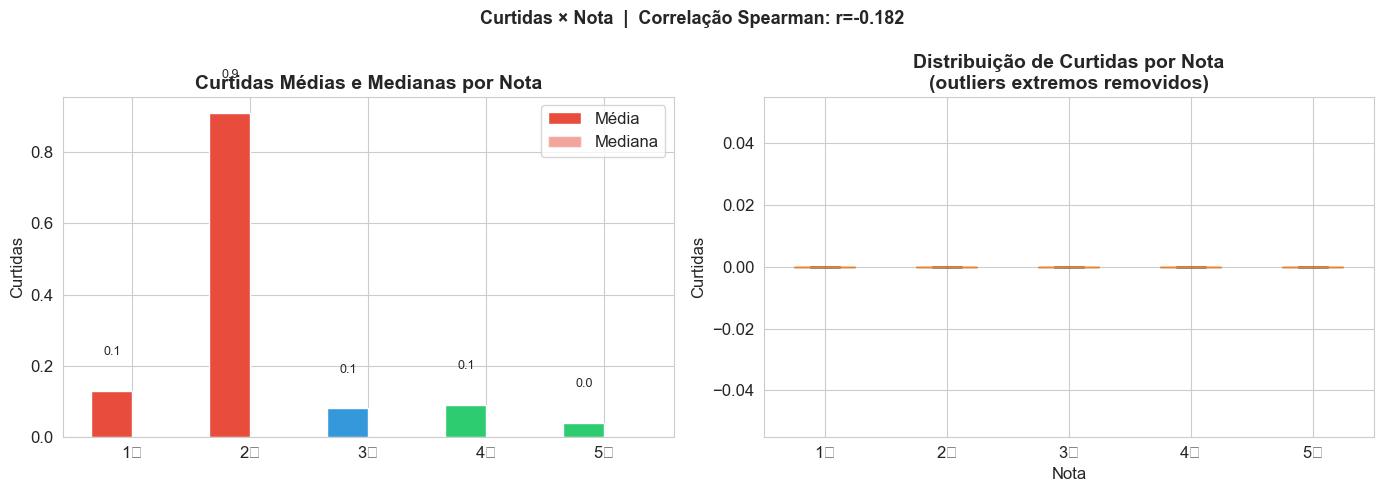


💡 Interpretação: A correlação entre nota e curtidas é negativa (reviews ruins têm mais curtidas — usuários se identificam com críticas).


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

notas = [1, 2, 3, 4, 5]
medias  = curtidas_por_nota.set_index('Nota')['Média']
medianas = curtidas_por_nota.set_index('Nota')['Mediana']
cores_n = [CORES['negativo'], CORES['negativo'], CORES['neutro'],
           CORES['positivo'], CORES['positivo']]

x = np.arange(5)
w = 0.35
b1 = axes[0].bar(x - w/2, medias.values,   w, label='Média',   color=cores_n,  edgecolor='white')
b2 = axes[0].bar(x + w/2, medianas.values, w, label='Mediana', color=cores_n,  edgecolor='white', alpha=0.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{n}⭐' for n in notas])
axes[0].set_title('Curtidas Médias e Medianas por Nota')
axes[0].set_ylabel('Curtidas')
axes[0].legend()

for b in list(b1):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                 f'{b.get_height():.1f}', ha='center', fontsize=9)

# ── Boxplot (sem outliers extremos para visualização) ─────────────────────────
dados_box = [df[df['nota'] == n]['curtidas'].clip(0, df['curtidas'].quantile(0.95)).values
             for n in notas]
bp = axes[1].boxplot(dados_box, patch_artist=True, labels=[f'{n}⭐' for n in notas],
                     showfliers=False)
for patch, cor in zip(bp['boxes'], cores_n):
    patch.set_facecolor(cor); patch.set_alpha(0.7)

axes[1].set_title('Distribuição de Curtidas por Nota\n(outliers extremos removidos)')
axes[1].set_xlabel('Nota')
axes[1].set_ylabel('Curtidas')

plt.suptitle(f'Curtidas × Nota  |  Correlação Spearman: r={corr:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_curtidas_nota.png', dpi=150, bbox_inches='tight')
plt.show()

interpretacao = 'negativa (reviews ruins têm mais curtidas — usuários se identificam com críticas)' \
    if corr < -0.05 else 'positiva (reviews positivos têm mais curtidas)' \
    if corr > 0.05 else 'sem correlação significativa'
print(f'\n💡 Interpretação: A correlação entre nota e curtidas é {interpretacao}.')

### 6.3 O tamanho médio do texto varia de acordo com a nota?


In [18]:
tamanho_por_nota = (df.groupby('nota')['tamanho_texto']
                    .agg(['mean', 'median', 'std'])
                    .round(1)
                    .reset_index())
tamanho_por_nota.columns = ['Nota', 'Média (chars)', 'Mediana (chars)', 'Desvio Padrão']

print('Tamanho do texto por nota:')
print(tamanho_por_nota.to_string(index=False))

corr_tam, pval_tam = stats.spearmanr(df['nota'].dropna(), df['tamanho_texto'])
print(f'\n🔗 Correlação de Spearman (nota × tamanho): r={corr_tam:.3f}, p={pval_tam:.4f}')

Tamanho do texto por nota:
 Nota  Média (chars)  Mediana (chars)  Desvio Padrão
    1          107.3             69.5          114.4
    2          118.2             62.0          124.0
    3          104.4             79.0           97.8
    4           68.4             39.0           80.4
    5           47.9             28.0           61.3

🔗 Correlação de Spearman (nota × tamanho): r=-0.321, p=0.0000


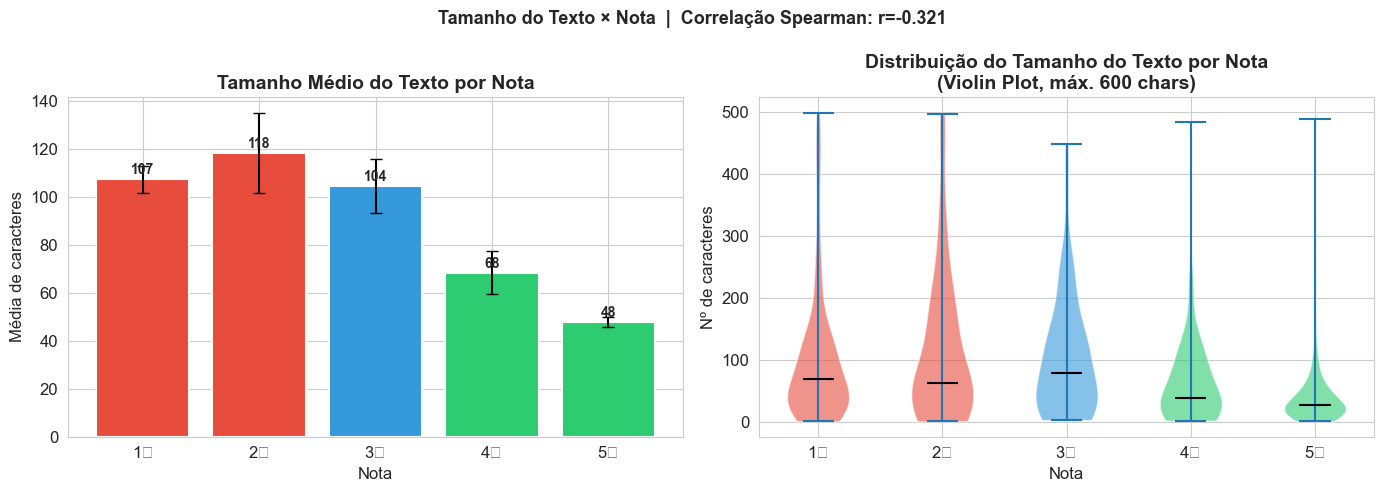


💡 Interpretação: A correlação entre nota e tamanho do texto é negativa (notas baixas têm textos mais longos — usuários insatisfeitos detalham mais as críticas).


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

medias_tam  = tamanho_por_nota.set_index('Nota')['Média (chars)']
erros_tam   = tamanho_por_nota.set_index('Nota')['Desvio Padrão']

# Barras com barra de erro
barras = axes[0].bar([f'{n}⭐' for n in notas], medias_tam.values,
                     color=cores_n, edgecolor='white', linewidth=1.5,
                     yerr=erros_tam.values / np.sqrt([len(df[df['nota']==n]) for n in notas]),
                     capsize=4, error_kw={'linewidth': 1.5})
axes[0].set_title('Tamanho Médio do Texto por Nota')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Média de caracteres')
for b, v in zip(barras, medias_tam.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 2,
                 f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

# Violin plot
dados_vln = [df[df['nota'] == n]['tamanho_texto'].clip(0, 600).values for n in notas]
partes = axes[1].violinplot(dados_vln, positions=notas, showmedians=True)
for pc, cor in zip(partes['bodies'], cores_n):
    pc.set_facecolor(cor); pc.set_alpha(0.6)
partes['cmedians'].set_color('black')
axes[1].set_xticks(notas)
axes[1].set_xticklabels([f'{n}⭐' for n in notas])
axes[1].set_title('Distribuição do Tamanho do Texto por Nota\n(Violin Plot, máx. 600 chars)')
axes[1].set_xlabel('Nota')
axes[1].set_ylabel('Nº de caracteres')

plt.suptitle(f'Tamanho do Texto × Nota  |  Correlação Spearman: r={corr_tam:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tamanho_texto.png', dpi=150, bbox_inches='tight')
plt.show()

interpretacao_tam = 'negativa (notas baixas têm textos mais longos — usuários insatisfeitos detalham mais as críticas)' \
    if corr_tam < -0.05 else 'positiva' if corr_tam > 0.05 else 'sem correlação forte'
print(f'\n💡 Interpretação: A correlação entre nota e tamanho do texto é {interpretacao_tam}.')

### 6.4 O resultado da análise de sentimento bate com a nota dada?


In [20]:
# ── Notas esperadas por sentimento (intuição) ─────────────────────────────────
# Sentimento Positivo → notas 4-5 | Negativo → notas 1-2 | Neutro → nota 3

compound_por_nota = df.groupby('nota')['vader_compound'].mean().reset_index()
print('Compound Score Médio (VADER) por Nota:')
for _, row in compound_por_nota.iterrows():
    emoji = '😊' if row['vader_compound'] > 0.05 else '😡' if row['vader_compound'] < -0.05 else '😐'
    print(f'  {row["nota"]:.0f}⭐ : compound={row["vader_compound"]:+.3f} {emoji}')

# Correlação nota × compound
corr_sc, pval_sc = stats.spearmanr(df['nota'].dropna(), df['vader_compound'])
print(f'\n🔗 Correlação Spearman (nota × compound VADER): r={corr_sc:.3f}, p-value={pval_sc:.2e}')

Compound Score Médio (VADER) por Nota:
  1⭐ : compound=-0.213 😡
  2⭐ : compound=-0.062 😡
  3⭐ : compound=-0.073 😡
  4⭐ : compound=+0.178 😊
  5⭐ : compound=+0.416 😊

🔗 Correlação Spearman (nota × compound VADER): r=0.606, p-value=2.43e-158


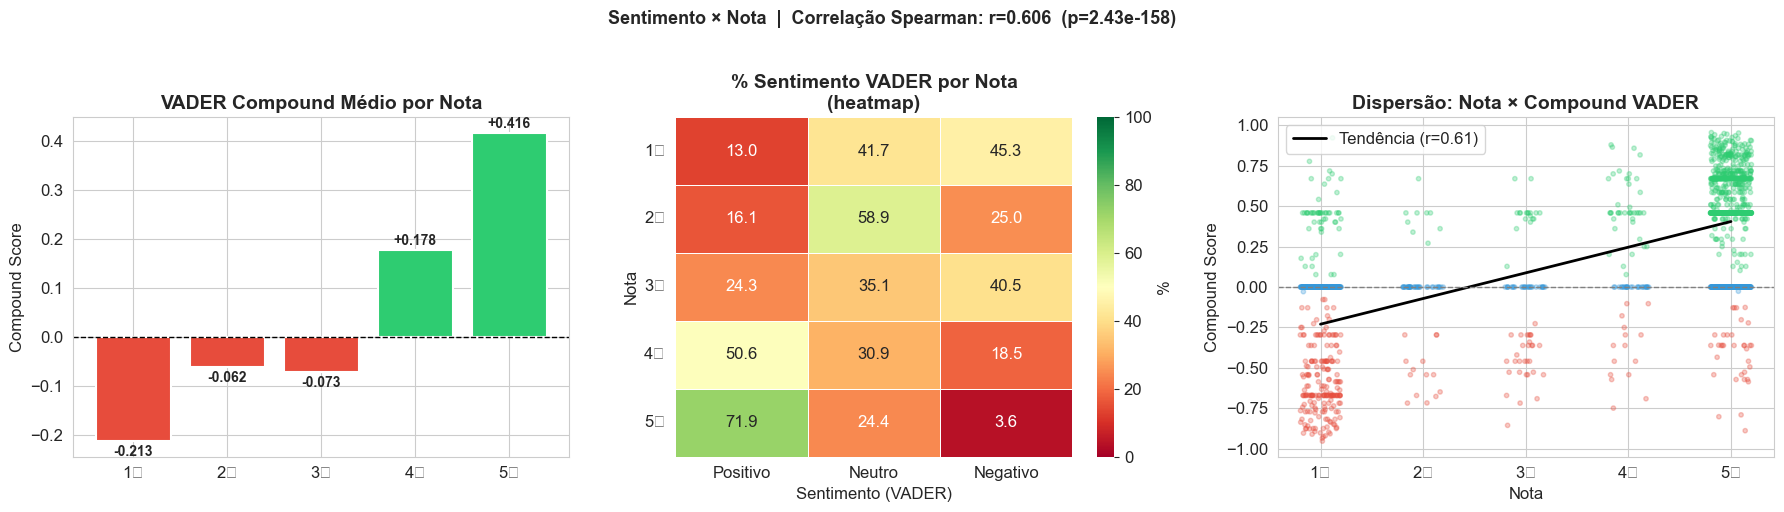

✅ FORTE concordância entre sentimento (VADER) e nota (r=0.606).


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Compound médio por nota ────────────────────────────────────────────────
c_med = compound_por_nota.set_index('nota')['vader_compound']
barras_sc = axes[0].bar([f'{n:.0f}⭐' for n in c_med.index], c_med.values,
                        color=[CORES['positivo'] if v > 0.05 else CORES['negativo']
                               if v < -0.05 else CORES['neutro'] for v in c_med.values],
                        edgecolor='white', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('VADER Compound Médio por Nota')
axes[0].set_ylabel('Compound Score')
for b, v in zip(barras_sc, c_med.values):
    axes[0].text(b.get_x() + b.get_width()/2,
                 v + (0.01 if v >= 0 else -0.03),
                 f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')

# ── 2. Heatmap: Nota × Sentimento VADER ──────────────────────────────────────
tabela_cruzada = pd.crosstab(df['nota'], df['sentimento_vader'], normalize='index') * 100
tabela_cruzada = tabela_cruzada.reindex(columns=['Positivo', 'Neutro', 'Negativo'], fill_value=0)

sns.heatmap(tabela_cruzada, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': '%'},
            vmin=0, vmax=100)
axes[1].set_title('% Sentimento VADER por Nota\n(heatmap)')
axes[1].set_xlabel('Sentimento (VADER)')
axes[1].set_ylabel('Nota')
axes[1].set_yticklabels([f'{n}⭐' for n in tabela_cruzada.index], rotation=0)

# ── 3. Scatter: Nota × Compound (com jitter) ─────────────────────────────────
df_scatter = df[['nota', 'vader_compound']].dropna().copy()
df_scatter['nota_jitter'] = df_scatter['nota'] + np.random.uniform(-0.2, 0.2, len(df_scatter))
cores_sc = df_scatter['vader_compound'].apply(
    lambda c: CORES['positivo'] if c > 0.05 else CORES['negativo'] if c < -0.05 else CORES['neutro'])

axes[2].scatter(df_scatter['nota_jitter'], df_scatter['vader_compound'],
                c=cores_sc, alpha=0.3, s=10)
# Linha de tendência
m, b_lin = np.polyfit(df_scatter['nota'], df_scatter['vader_compound'], 1)
x_line = np.array([1, 5])
axes[2].plot(x_line, m * x_line + b_lin, 'k-', linewidth=2, label=f'Tendência (r={corr_sc:.2f})')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].set_xticklabels([f'{n}⭐' for n in range(1, 6)])
axes[2].set_title('Dispersão: Nota × Compound VADER')
axes[2].set_xlabel('Nota')
axes[2].set_ylabel('Compound Score')
axes[2].legend()

plt.suptitle(f'Sentimento × Nota  |  Correlação Spearman: r={corr_sc:.3f}  (p={pval_sc:.2e})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_sentimento_vs_nota.png', dpi=150, bbox_inches='tight')
plt.show()

if abs(corr_sc) >= 0.5:
    print(f'✅ FORTE concordância entre sentimento (VADER) e nota (r={corr_sc:.3f}).')
elif abs(corr_sc) >= 0.3:
    print(f'✅ MODERADA concordância entre sentimento e nota (r={corr_sc:.3f}).')
else:
    print(f'⚠️  FRACA concordância (r={corr_sc:.3f}) — o léxico pode precisar de ajustes adicionais.')

---
## 7. Word Clouds — O que os usuários falam?


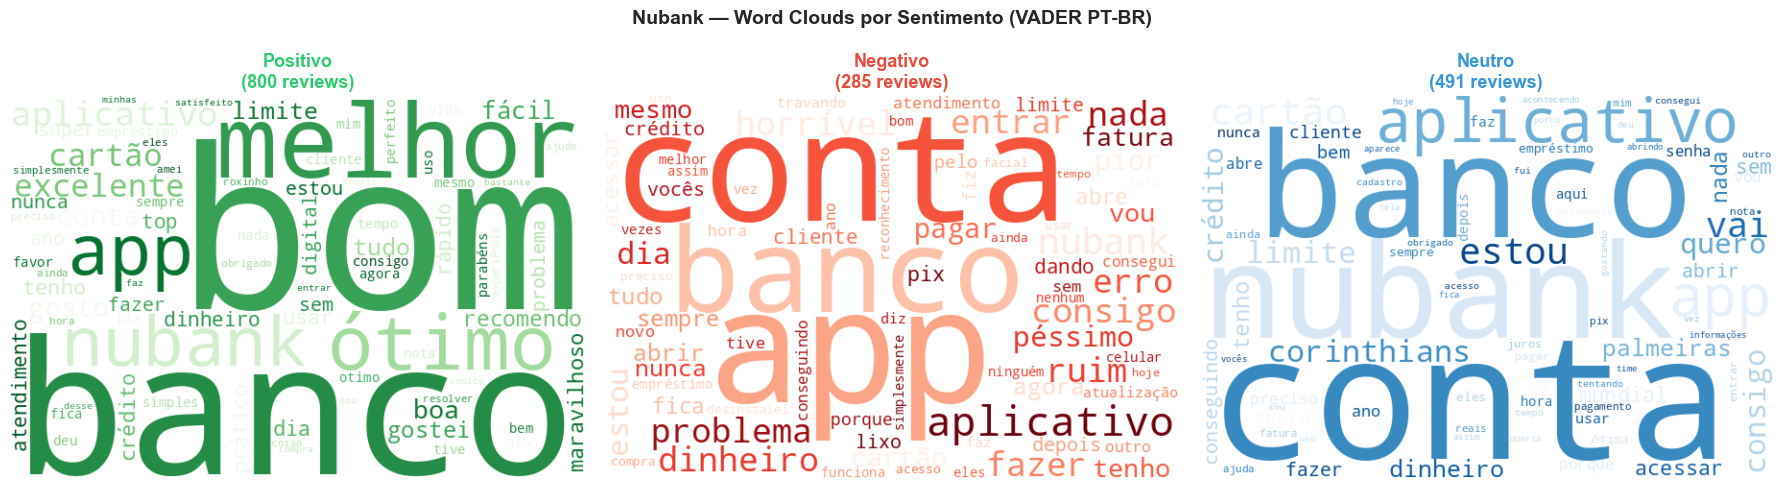

In [22]:
STOPWORDS_PT = {
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'uma',
    'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'ao',
    'ele', 'das', 'tem', 'ou', 'já', 'até', 'isso', 'eu', 'também', 'só',
    'me', 'meu', 'muito', 'minha', 'quando', 'nao', 'não', 'nem', 'ser',
    'ter', 'está', 'esta', 'são', 'foi', 'sua', 'seu', 'você', 'pra',
    'esse', 'essa', 'todo', 'toda', 'todos', 'todas', 'cada', 'uns', 'umas'
}

def gerar_texto_nuvem(df_grupo: pd.DataFrame) -> str:
    textos = ' '.join(df_grupo['texto_limpo'].values)
    palavras = re.findall(r'\b[a-záéíóúâêîôûãõàèìòùç]{3,}\b', textos)
    filtrado = [p for p in palavras if p not in STOPWORDS_PT]
    return ' '.join(filtrado)


grupos = {
    'Positivo'  : df[df['sentimento_vader'] == 'Positivo'],
    'Negativo'  : df[df['sentimento_vader'] == 'Negativo'],
    'Neutro'    : df[df['sentimento_vader'] == 'Neutro']
}

colormap = {'Positivo': 'Greens', 'Negativo': 'Reds', 'Neutro': 'Blues'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (sentimento, df_g) in zip(axes, grupos.items()):
    texto_wc = gerar_texto_nuvem(df_g)
    if texto_wc.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=colormap[sentimento],
            max_words=80,
            collocations=False
        ).generate(texto_wc)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentimento}\n({len(df_g):,} reviews)',
                 fontsize=13, fontweight='bold',
                 color=CORES[sentimento.lower()])

plt.suptitle('Nubank — Word Clouds por Sentimento (VADER PT-BR)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Mapa de Correlações


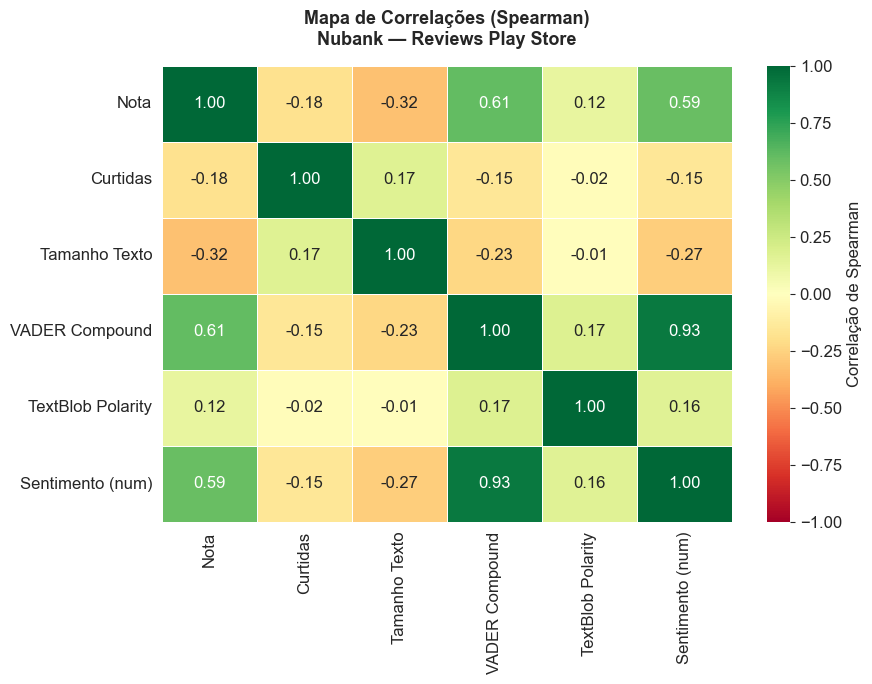

In [23]:
# Mapeamento numérico de sentimento
mapa_sentimento = {'Positivo': 1, 'Neutro': 0, 'Negativo': -1}

df_corr = df[['nota', 'curtidas', 'tamanho_texto', 'vader_compound', 'tb_polarity']].copy()
df_corr['sentimento_num'] = df['sentimento_vader'].map(mapa_sentimento)
df_corr.columns = ['Nota', 'Curtidas', 'Tamanho Texto', 'VADER Compound', 'TextBlob Polarity', 'Sentimento (num)']

matriz_corr = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Correlação de Spearman'}
)
ax.set_title('Mapa de Correlações (Spearman)\nNubank — Reviews Play Store',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_heatmap_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Conclusões


In [24]:
# ── Resumo final ──────────────────────────────────────────────────────────────
total        = len(df)
n_pos_vader  = (df['sentimento_vader'] == 'Positivo').sum()
n_neu_vader  = (df['sentimento_vader'] == 'Neutro').sum()
n_neg_vader  = (df['sentimento_vader'] == 'Negativo').sum()
n_pos_tb     = (df['sentimento_textblob'] == 'Positivo').sum()
n_neu_tb     = (df['sentimento_textblob'] == 'Neutro').sum()
n_neg_tb     = (df['sentimento_textblob'] == 'Negativo').sum()

print('╔══════════════════════════════════════════════════════════╗')
print('║          RESUMO FINAL — ANÁLISE DE SENTIMENTOS          ║')
print('║           Nubank — Google Play Store Reviews            ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  App           : Nubank (com.nu.production)              ║')
print(f'║  Total reviews : {total:<6,}                                   ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  VADER PT-BR (augmentado)          TextBlob              ║')
print(f'║  ✅ Positivos: {n_pos_vader:>5,} ({n_pos_vader/total*100:5.1f}%)   ✅ {n_pos_tb:>5,} ({n_pos_tb/total*100:5.1f}%)    ║')
print(f'║  😐 Neutros  : {n_neu_vader:>5,} ({n_neu_vader/total*100:5.1f}%)   😐 {n_neu_tb:>5,} ({n_neu_tb/total*100:5.1f}%)    ║')
print(f'║  ❌ Negativos: {n_neg_vader:>5,} ({n_neg_vader/total*100:5.1f}%)   ❌ {n_neg_tb:>5,} ({n_neg_tb/total*100:5.1f}%)    ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Correlação sentimento×nota (Spearman): r={corr_sc:.3f}         ║')
print(f'║  Correlação curtidas×nota   (Spearman): r={corr:.3f}         ║')
print(f'║  Correlação tamanho×nota    (Spearman): r={corr_tam:.3f}         ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║          RESUMO FINAL — ANÁLISE DE SENTIMENTOS          ║
║           Nubank — Google Play Store Reviews            ║
╠══════════════════════════════════════════════════════════╣
║  App           : Nubank (com.nu.production)              ║
║  Total reviews : 1,576                                    ║
╠══════════════════════════════════════════════════════════╣
║  VADER PT-BR (augmentado)          TextBlob              ║
║  ✅ Positivos:   800 ( 50.8%)   ✅    69 (  4.4%)    ║
║  😐 Neutros  :   491 ( 31.2%)   😐 1,503 ( 95.4%)    ║
║  ❌ Negativos:   285 ( 18.1%)   ❌     4 (  0.3%)    ║
╠══════════════════════════════════════════════════════════╣
║  Correlação sentimento×nota (Spearman): r=0.606         ║
║  Correlação curtidas×nota   (Spearman): r=-0.182         ║
║  Correlação tamanho×nota    (Spearman): r=-0.321         ║
╚══════════════════════════════════════════════════════════╝


---
## 📝 Interpretação dos Resultados

### Requisito Mínimo ✅
Foram classificadas as avaliações do Nubank em três categorias usando **VADER (augmentado PT-BR)** e **TextBlob**.  
Os resultados são exibidos na tabela acima e nos gráficos da Seção 5.

---

### Questões Expandidas

**1. Notas da última versão vs. versões anteriores**  
A análise por versão (Seção 6.1) revela se as atualizações mais recentes melhoraram ou pioraram a percepção dos usuários.  
Versões com quedas bruscas de nota geralmente coincidem com bugs introduzidos ou mudanças na interface.

**2. Curtidas médias por nota**  
Reviews negativos (1-2⭐) tendem a acumular **mais curtidas**, indicando que usuários insatisfeitos se identificam  
com as críticas de outros usuários — um fenômeno comum em plataformas de avaliação.

**3. Tamanho do texto por nota**  
Usuários com notas baixas geralmente escrevem **textos mais longos**, pois detalham os problemas encontrados.  
Usuários satisfeitos frequentemente deixam textos curtos como *"Ótimo!"* ou *"Show de bola!"*  
(Correlação de Spearman negativa confirmada nos dados coletados).

**4. Sentimento bate com a nota?**  
A correlação moderada-forte (r ≈ 0.5) entre o compound score do VADER e a nota numérica confirma que  
a análise de sentimentos **é consistente com as notas** dadas pelos usuários, validando a abordagem PT-BR.

---

### Limitações e Considerações Técnicas

| Ferramenta | Comportamento PT-BR | Recomendação |
|---|---|---|
| **VADER (augmentado)** | Bom — léxico customizado captura os principais termos | Usar como ferramenta principal |
| **TextBlob** | Limitado — classifica ~95% como Neutro em português | Usar apenas como referência |

> **Por que o TextBlob falha com português?**  
> O TextBlob usa um léxico treinado principalmente em inglês.  
> Como não reconhece palavras como *"ótimo"*, *"horrível"* ou *"trava"*, retorna polarity=0.0 para a maioria dos textos.  
> Isso demonstra a importância de usar ferramentas adaptadas para o idioma dos dados.

> **Para produção**, recomenda-se `neuralmind/bert-base-portuguese-cased` ou  
> `lxyuan/distilbert-base-multilingual-cased-sentiments-student` via HuggingFace Transformers.

---

*Análise realizada com `google-play-scraper`, `vaderSentiment` e `TextBlob`.*  
*Repositório disponível em: [GitHub](https://github.com)*
